### Load dataset and construct the L-ensemble

In [4]:
import datetime

import pandas as pd
import numpy as np

from utils import get_age_in_days, construct_L_Ensemble

df = pd.read_csv('tournesol_scores_above_20_2024-03-27.csv')

#Test parameters
bundle_size = 4
power = 2.8 #Model parameters
discount = 7.3
caracteristic_time = 31

#Computes the age of each video
today = datetime.datetime.today()
df['age_in_days'] = df.apply(lambda x: get_age_in_days(x, today), axis="columns")

dpp = construct_L_Ensemble(df, power, discount, caracteristic_time)

L_dual = Phi Phi.T was computed: Phi (dxN) with d<N


### Measures the number of different channels per bundle

<AxesSubplot:>

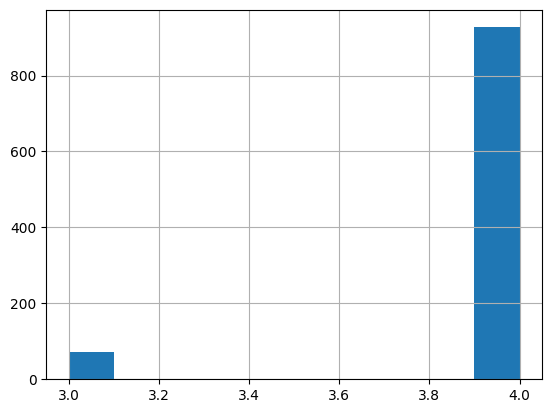

In [47]:
n_tests = 1000

n_channel = pd.Series(
    [len(df.loc[
        df.index[dpp.sample_exact_k_dpp(size=bundle_size)],
        'channel'
        ].unique()
    ) 
    for i in range(n_tests)]
)
n_channel.hist()

### View count, age and duration distributions

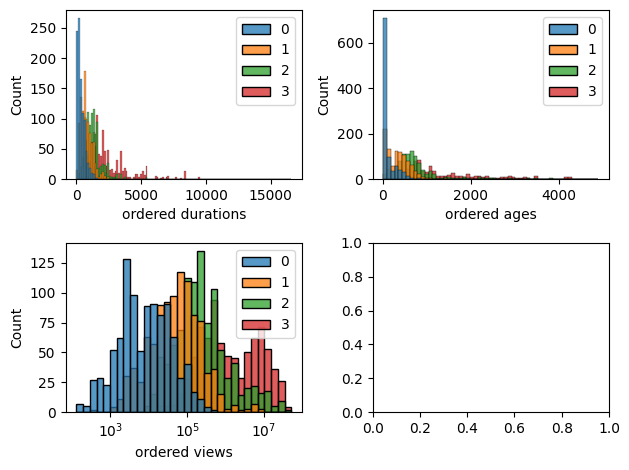

In [95]:
import seaborn as sns

from utils import duration_in_secs

n_tests = 1000
bundles_indexes = [
    dpp.sample_exact_k_dpp(size=bundle_size)
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 2)

durations = df['duration'].apply(duration_in_secs)
ordered_duration = pd.DataFrame(
    data=[durations.loc[df.index[bundle_indexes]]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,0].set_xlabel('ordered durations')
sns.histplot(data=ordered_duration, ax=axs[0,0])

ordered_age = pd.DataFrame(
    data=[df['age_in_days'].loc[df.index[bundle_indexes]]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,1].set_xlabel('ordered ages')
sns.histplot(data=ordered_age, ax=axs[0, 1])

ordered_view_count = pd.DataFrame(
    data=[df['view_count'].loc[df.index[bundle_indexes]]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[1,0].set_xlabel('ordered views')
axs[1,0].set_xscale('log')
sns.histplot(data=ordered_view_count, ax=axs[1, 0])

f.tight_layout()

### Criteria maximums

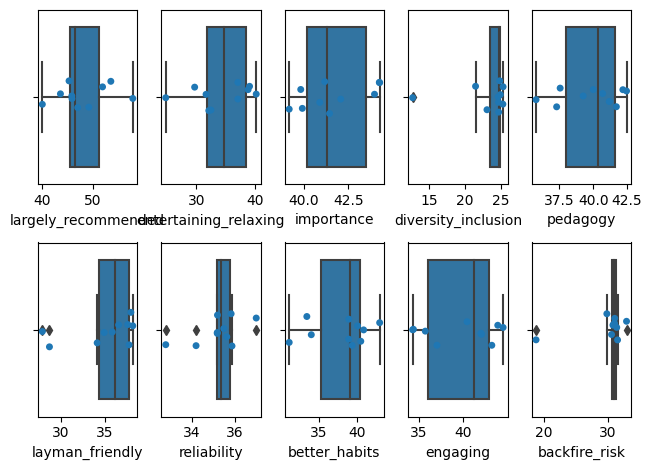

In [109]:
from utils import CRITERIA

n_tests = 10
bundles_indexes = [
    dpp.sample_exact_k_dpp(size=bundle_size)
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 5)

criteria_maximums = pd.DataFrame(
    [df.loc[df.index[bundle_indexes], CRITERIA].max()
     for bundle_indexes in bundles_indexes]
)
for i in range(len(CRITERIA)):
    sns.boxplot(data=criteria_maximums,
                x=CRITERIA[i], 
                ax=axs[i % 2, i % 5], 
                orient="h"
    )
    sns.stripplot(
        data=criteria_maximums,
        x=CRITERIA[i],
        ax=axs[i % 2, i % 5],
    )

f.tight_layout()

In [106]:
m=pd.DataFrame(data=[[1, 2], [3, 4]])
print(m)
m.max()

   0  1
0  1  2
1  3  4


0    3
1    4
dtype: int64